In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)


In [2]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [3]:
DB_PATH = Path("../olist.db")
ORDER_STATUS_FILTER = "delivered"

FORECAST_HORIZON = 3   # months ahead
TEST_MONTHS = 3        # holdout window
MIN_ORDERS_PER_MONTH = 50  # remove launch noise


In [4]:
with sqlite3.connect(DB_PATH) as conn:
    orders = pd.read_sql(
        """
        SELECT
            order_id,
            customer_unique_id,
            order_purchase_date,
            total_payment_value
        FROM fact_orders
        WHERE order_status = ?
        """,
        conn,
        params=(ORDER_STATUS_FILTER,),
        parse_dates=["order_purchase_date"],
    )

orders.shape


(96478, 4)

In [5]:
orders["total_payment_value"] = (
    orders["total_payment_value"]
    .fillna(0)
    .clip(lower=0)
)

assert orders["total_payment_value"].ge(0).all()
orders["total_payment_value"].describe()


count    96478.000000
mean       159.854700
std        218.812616
min          0.000000
25%         61.880000
50%        105.280000
75%        176.330000
max      13664.080000
Name: total_payment_value, dtype: float64

In [6]:
monthly = (
    orders
    .assign(month=orders["order_purchase_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(
        revenue=("total_payment_value", "sum"),
        orders=("order_id", "nunique")
    )
    .sort_values("month")
)

monthly.head(), monthly.tail()


(       month    revenue  orders
 0 2016-09-01       0.00       1
 1 2016-10-01   46566.71     265
 2 2016-12-01      19.62       1
 3 2017-01-01  127545.67     750
 4 2017-02-01  271298.65    1653,
         month     revenue  orders
 18 2018-04-01  1132933.95    6798
 19 2018-05-01  1128836.69    6749
 20 2018-06-01  1012090.68    6099
 21 2018-07-01  1027903.86    6159
 22 2018-08-01   985414.28    6351)

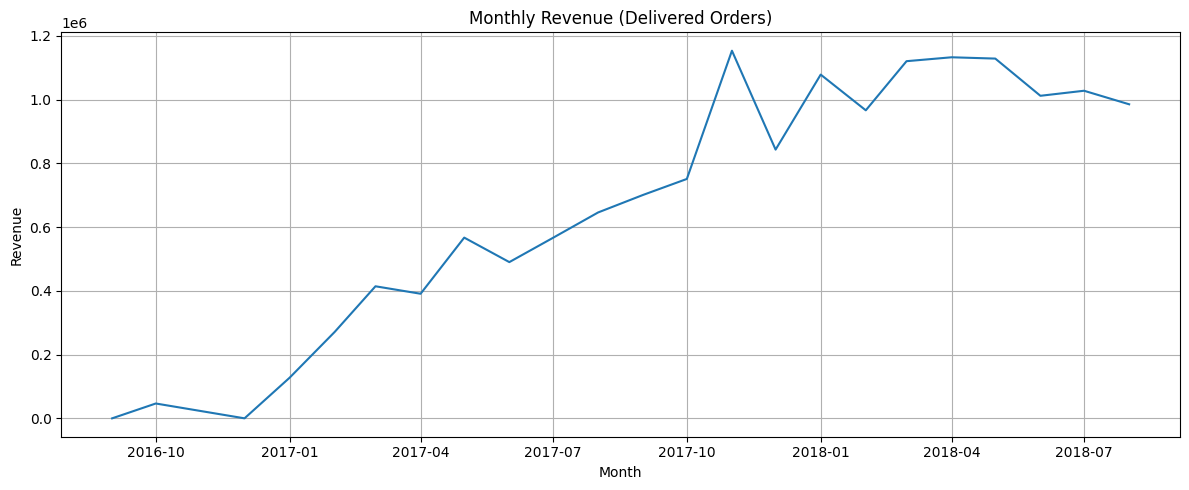

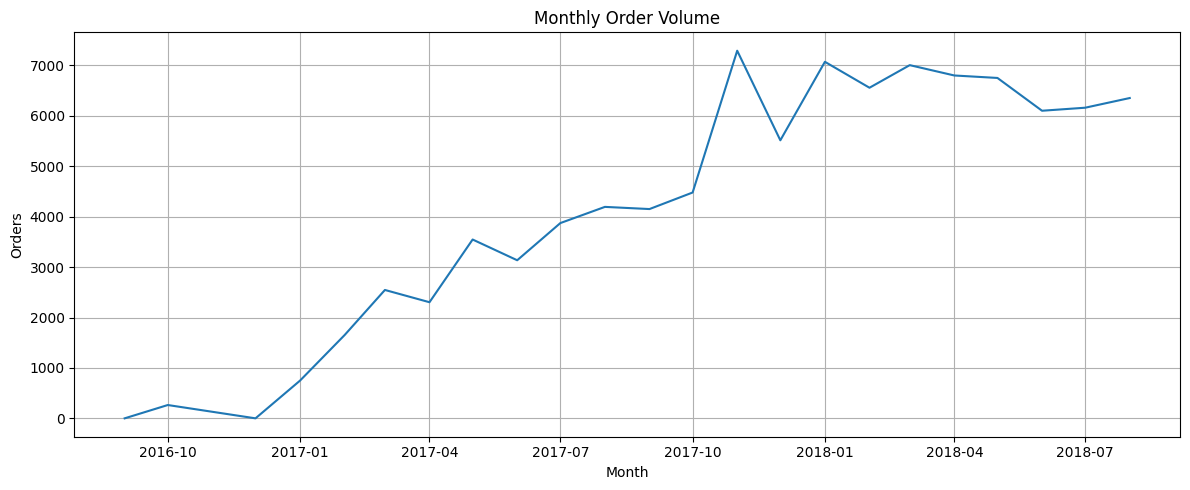

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(monthly["month"], monthly["revenue"])
plt.title("Monthly Revenue (Delivered Orders)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(monthly["month"], monthly["orders"])
plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.grid(True)
plt.tight_layout()
plt.show()


In [8]:
monthly_model = monthly.loc[
    monthly["orders"] >= MIN_ORDERS_PER_MONTH
].copy()

monthly_model.reset_index(drop=True, inplace=True)
monthly_model.shape


(21, 3)

In [9]:
ts = (
    monthly_model
    .set_index("month")["revenue"]
    .asfreq("MS")
)

ts.isna().sum(), ts.index.min(), ts.index.max()


(np.int64(2),
 Timestamp('2016-10-01 00:00:00'),
 Timestamp('2018-08-01 00:00:00'))

In [10]:
train = ts.iloc[:-TEST_MONTHS]
test = ts.iloc[-TEST_MONTHS:]

train.shape, test.shape


((20,), (3,))

In [11]:
print("Total months:", ts.shape[0])
print("Training months:", train.shape[0])
print("Test months:", test.shape[0])


Total months: 23
Training months: 20
Test months: 3


In [12]:
def naive_forecast(train_series, steps):
    idx = pd.date_range(
        train_series.index[-1] + pd.offsets.MonthBegin(1),
        periods=steps,
        freq="MS"
    )
    return pd.Series([train_series.iloc[-1]] * steps, index=idx)


def seasonal_naive_forecast(train_series, steps, season_length=12):
    if len(train_series) < season_length:
        return None
    last_season = train_series.iloc[-season_length:]
    reps = int(np.ceil(steps / season_length))
    values = np.tile(last_season.values, reps)[:steps]
    idx = pd.date_range(
        train_series.index[-1] + pd.offsets.MonthBegin(1),
        periods=steps,
        freq="MS"
    )
    return pd.Series(values, index=idx)


naive_pred = naive_forecast(train, len(test))
seasonal_naive_pred = seasonal_naive_forecast(train, len(test))


In [13]:
def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def mape(y_true, y_pred):
    nonzero = y_true != 0
    return float(np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])))


In [14]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

use_seasonal = len(train) >= 24
print("Using seasonal ETS:", use_seasonal)

candidates = []

def fit_ets(train_series, trend, damped, seasonal):
    model = ExponentialSmoothing(
        train_series,
        trend=trend,
        damped_trend=damped,
        seasonal=seasonal,
        seasonal_periods=(12 if seasonal else None),
        initialization_method="estimated",
    )
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always", ConvergenceWarning)
        fit = model.fit(optimized=True)
        conv_warn = any(isinstance(wi.message, ConvergenceWarning) for wi in w)
    return fit, conv_warn

# Candidate set (seasonal only if we have enough history)
seasonal_component = "add" if use_seasonal else None

# 1) Trend-only (your current)
fit1, warn1 = fit_ets(train, trend="add", damped=False, seasonal=seasonal_component)
pred1 = fit1.forecast(len(test))
candidates.append(("ETS: add trend", pred1, warn1))

# 2) Damped trend (often more stable)
fit2, warn2 = fit_ets(train, trend="add", damped=True, seasonal=seasonal_component)
pred2 = fit2.forecast(len(test))
candidates.append(("ETS: damped trend", pred2, warn2))

# 3) No trend (simpler baseline ETS)
fit3, warn3 = fit_ets(train, trend=None, damped=False, seasonal=seasonal_component)
pred3 = fit3.forecast(len(test))
candidates.append(("ETS: no trend", pred3, warn3))

candidates[0][0], candidates[0][2]


Using seasonal ETS: False


('ETS: add trend', True)

In [15]:
rows = []

# Baseline: Naive
rows.append({
    "model": "Naive",
    "MAE": mae(test.values, naive_pred.values),
    "MAPE": mape(test.values, naive_pred.values),
    "convergence_warning": False
})

# Baseline: Seasonal Naive (if available)
if seasonal_naive_pred is not None:
    rows.append({
        "model": "Seasonal Naive",
        "MAE": mae(test.values, seasonal_naive_pred.values),
        "MAPE": mape(test.values, seasonal_naive_pred.values),
        "convergence_warning": False
    })

# ETS candidates
for name, pred, conv_warn in candidates:
    rows.append({
        "model": name,
        "MAE": mae(test.values, pred.values),
        "MAPE": mape(test.values, pred.values),
        "convergence_warning": conv_warn
    })

results = pd.DataFrame(rows).sort_values("MAPE")
results


,model,MAE,MAPE,convergence_warning
0,Naive,120367.083333,0.119696,False
1,Seasonal Naive,440926.226667,0.436347,False
2,ETS: add trend,NaN,NaN,True
3,ETS: damped trend,NaN,NaN,True
4,ETS: no trend,NaN,NaN,True


Best model: Naive


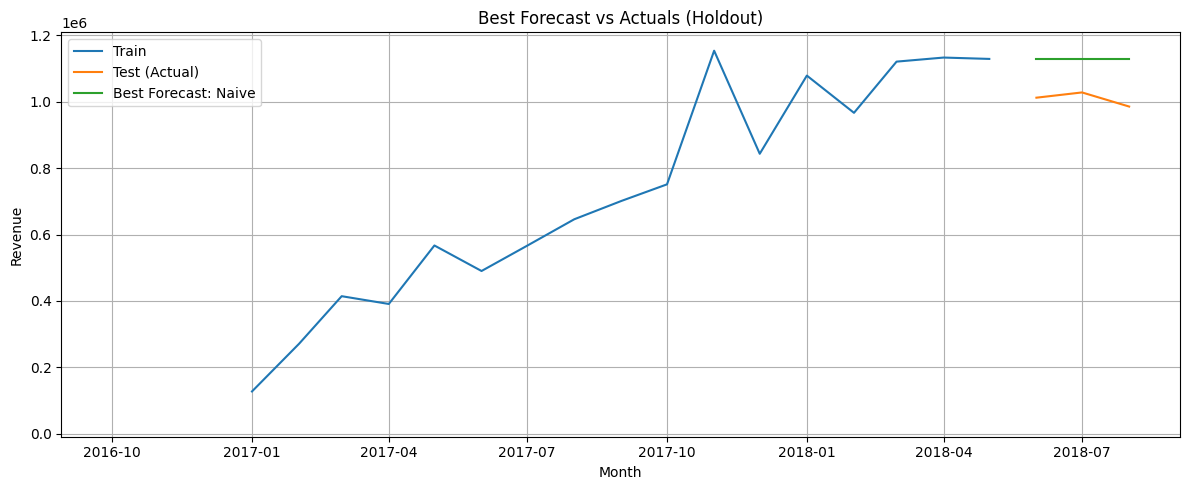

In [16]:
best_name = results.iloc[0]["model"]
print("Best model:", best_name)

def get_pred_by_name(name):
    if name == "Naive":
        return naive_pred
    if name == "Seasonal Naive":
        return seasonal_naive_pred
    for n, p, _ in candidates:
        if n == name:
            return p
    raise ValueError("Unknown model name")

best_pred = get_pred_by_name(best_name)

plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Test (Actual)")
plt.plot(best_pred.index, best_pred.values, label=f"Best Forecast: {best_name}")
plt.title("Best Forecast vs Actuals (Holdout)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
final_train = ts
best_name = results.iloc[0]["model"]

if best_name.startswith("ETS"):
    # choose configuration from name
    use_seasonal_full = len(final_train) >= 24
    seasonal_component_full = "add" if use_seasonal_full else None

    if best_name == "ETS: add trend":
        final_fit, _ = fit_ets(final_train, trend="add", damped=False, seasonal=seasonal_component_full)
    elif best_name == "ETS: damped trend":
        final_fit, _ = fit_ets(final_train, trend="add", damped=True, seasonal=seasonal_component_full)
    elif best_name == "ETS: no trend":
        final_fit, _ = fit_ets(final_train, trend=None, damped=False, seasonal=seasonal_component_full)
    else:
        raise ValueError("Unexpected ETS model name.")

    future_forecast = final_fit.forecast(FORECAST_HORIZON)

elif best_name == "Seasonal Naive":
    future_forecast = seasonal_naive_forecast(final_train, FORECAST_HORIZON)

else:
    future_forecast = naive_forecast(final_train, FORECAST_HORIZON)

future_forecast


2018-09-01    985414.28
2018-10-01    985414.28
2018-11-01    985414.28
Freq: MS, dtype: float64

In [18]:
# Ensure processed folder exists
Path("../data/processed").mkdir(exist_ok=True)

# Save forecast values
future_forecast.to_frame("forecast_revenue").to_csv(
    "../data/processed/revenue_forecast_total.csv"
)

# Save model comparison
results.to_csv(
    "../data/processed/forecast_model_comparison.csv",
    index=False
)

print("Saved:")
print("- data/processed/revenue_forecast_total.csv")
print("- data/processed/forecast_model_comparison.csv")


Saved:
- data/processed/revenue_forecast_total.csv
- data/processed/forecast_model_comparison.csv
